In [32]:
import os, sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import math

from lowRank.NMLRSSE_Strang_CUDA import NMLRSSE_Strang_CUDA
from lowRank import compute_expectation as ce
from utils.noise_generator import ColoredNoiseGenerator_Cholesky
from utils import multi_index

# SIAM-style plotting setup: clean, publication-friendly, and readable in grayscale.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 20,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "legend.fontsize": 13,
    "legend.frameon": False,
})

def apply_light_paper_grid(ax):
    # 开启次刻度，否则 minor grid 通常不会显示出来
    # ax.minorticks_on()
    # 主网格：稍微深一点，用细实线
    ax.grid(which="major", color="#DDDDDD", linestyle='-', alpha=0.6, lw=0.6)
    # 次网格：非常浅，用点线或极细虚线
    ax.grid(which="minor", color="#EEEEEE", linestyle=':', alpha=0.3, lw=0.4)
    # 隐藏不必要的刻度线
    ax.tick_params(which='major', direction='in')

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
xi = 0.2
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((xi * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# spin-boson model parameters
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

### Test convergence order of N

MultiIndex layers: 100%|██████████| 17/17 [00:00<00:00, 52583.46it/s]


Low-rank decomposition done in 0.24 seconds.


Trajectory batches: 100%|██████████| 16/16 [00:00<00:00, 20.52it/s]


Low-rank decomposition done in 0.24 seconds.


MultiIndex layers: 100%|██████████| 3/3 [00:00<00:00, 26546.23it/s]


...

MultiIndex layers: 100%|██████████| 8/8 [00:00<00:00, 630.58it/s]


Low-rank decomposition done in 0.23 seconds.


MultiIndex layers: 100%|██████████| 9/9 [00:03<00:00,  2.46it/s]


Low-rank decomposition done in 0.24 seconds.


Trajectory batches: 100%|██████████| 16/16 [00:01<00:00, 12.50it/s]
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


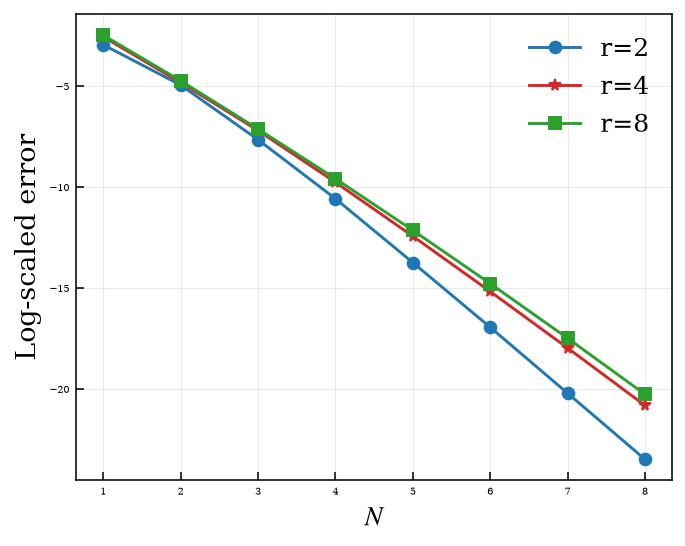

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


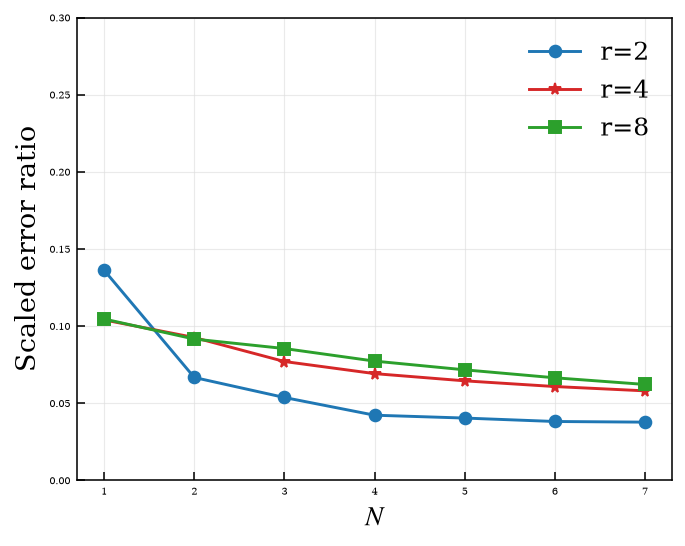

In [33]:
tmax = 5.0 / Delta
N_steps = 100
psi0 = np.array([1.0, 0.0], dtype=complex)
N_trajs = 1000
parallel_traj = True
ranks = [2,4,8]
max_layer = [1,2,3,4,5,6,7,8]

errors = [[], [], []]
err_scaled = [[], [], []]
err_transformed = [[], [], []]
colors = ["tab:blue", "tab:red", "tab:green"]
markers = ["o", "*", "s"]

# reference nosie trajectories
noise_gen = ColoredNoiseGenerator_Cholesky(alpha=bath_corr, t_stop=tmax, N_steps=N_steps)
Z = np.empty((N_trajs, N_steps + 1), dtype=np.complex128)
for idx in range(N_trajs):
    Z[idx,:] = noise_gen.sample_process()

for num, rank in enumerate(ranks):
    # reference solution
    NMLRSSE_solver = NMLRSSE_Strang_CUDA(
        Hs = Hs[1],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = N_steps,
        rank = rank,
        max_layer = 16,
        noise_sample_Z=Z
    )
    ref_psis = NMLRSSE_solver.solve(N_trajs, psi0)

    for ml in max_layer:
        NMLRSSE_solver = NMLRSSE_Strang_CUDA(
            Hs = Hs[1],
            L = L,
            bath_corr = bath_corr,
            tmax = tmax,
            N_steps = N_steps,
            rank = rank,
            max_layer = ml,
            noise_sample_Z=Z
        )
        psis = NMLRSSE_solver.solve(N_trajs, psi0)
        err = ref_psis - psis
        err_norm = np.linalg.norm(err, axis=-1)
        traj_max = err_norm.max(axis=-1)
        errors[num].append(traj_max.mean())

    for idx in range(len(max_layer)-1):
        err_transformed[num].append(errors[num][idx+1]/errors[num][idx] * np.sqrt(max_layer[idx+1]))

    for idx in range(len(max_layer)):
        err_scaled[num].append(np.log(errors[num][idx] * np.sqrt(math.factorial(max_layer[idx]))))

fig1, ax1 = plt.subplots(figsize=(5, 4))
for idx in range(len(ranks)):
    ax1.plot(range(1, len(max_layer)+1), err_scaled[idx],
             color=colors[idx], lw=1.5, marker=markers[idx],
             label=f"r={ranks[idx]}")
ax1.set_xlabel(r"$N$")
ax1.set_ylabel("Log-scaled error")
ax1.legend()
apply_light_paper_grid(ax1)
plt.tight_layout()
plt.savefig("figures/convergence_order_1.eps", format="eps")
plt.show()

fig2, ax2 = plt.subplots(figsize=(5, 4))
for idx in range(len(ranks)):
    ax2.plot(range(1, len(max_layer)), err_transformed[idx],
             color=colors[idx], lw=1.5, marker=markers[idx],
             label=f"r={ranks[idx]}")
ax2.set_ylim(0, 0.3)
ax2.set_xlabel(r"$N$")
ax2.set_ylabel("Scaled error ratio")
ax2.legend()
apply_light_paper_grid(ax2)
plt.tight_layout()
plt.savefig("figures/convergence_order_2.eps", format="eps")
plt.show()